<a href="https://colab.research.google.com/github/richardparik/Projects/blob/master/FINAL%20project/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor

Dataset k projektu
https://www.kaggle.com/datasets/denizkavi1/brain-tumor?resource=download

1. 1 Meningioma samples (708 files)
2. 2 Glioma samples (1426 files)
3. 3 Pituitary tumor samples (930 files)



# Step 1: Understanding the Dataset
Download the dataset from Kaggle.
Explore the dataset structure (number of classes, sample images, etc.).
Check for data imbalances and preprocessing needs.


## Download and extraxt dataset, locate the Extracted Dataset

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("denizkavi1/brain-tumor")

print("Path to dataset files:", path)

100%|██████████| 700M/700M [00:15<00:00, 47.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/denizkavi1/brain-tumor/versions/2


In [9]:
#This will confirm the dataset folder structure.
import os

dataset_root = "/root/.cache/kagglehub/datasets/denizkavi1/brain-tumor/versions/"
print("Available dataset versions:", os.listdir(dataset_root))

# Select the latest version
latest_version = os.listdir(dataset_root)[-1]  # Get the most recent version
dataset_path = os.path.join(dataset_root, latest_version)
print("Using dataset path:", dataset_path)

# List classes inside the dataset
print("Dataset structure:", os.listdir(dataset_path))


Available dataset versions: ['2']
Using dataset path: /root/.cache/kagglehub/datasets/denizkavi1/brain-tumor/versions/2
Dataset structure: ['1', '2', '3']


## Count Images Per Category

In [10]:
#Count Images Per Category
# Count images in each category
for category in os.listdir(dataset_path):
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):
        print(f"{category}: {len(os.listdir(category_path))} images")


1: 708 images
2: 1426 images
3: 930 images


## Display Sample Images

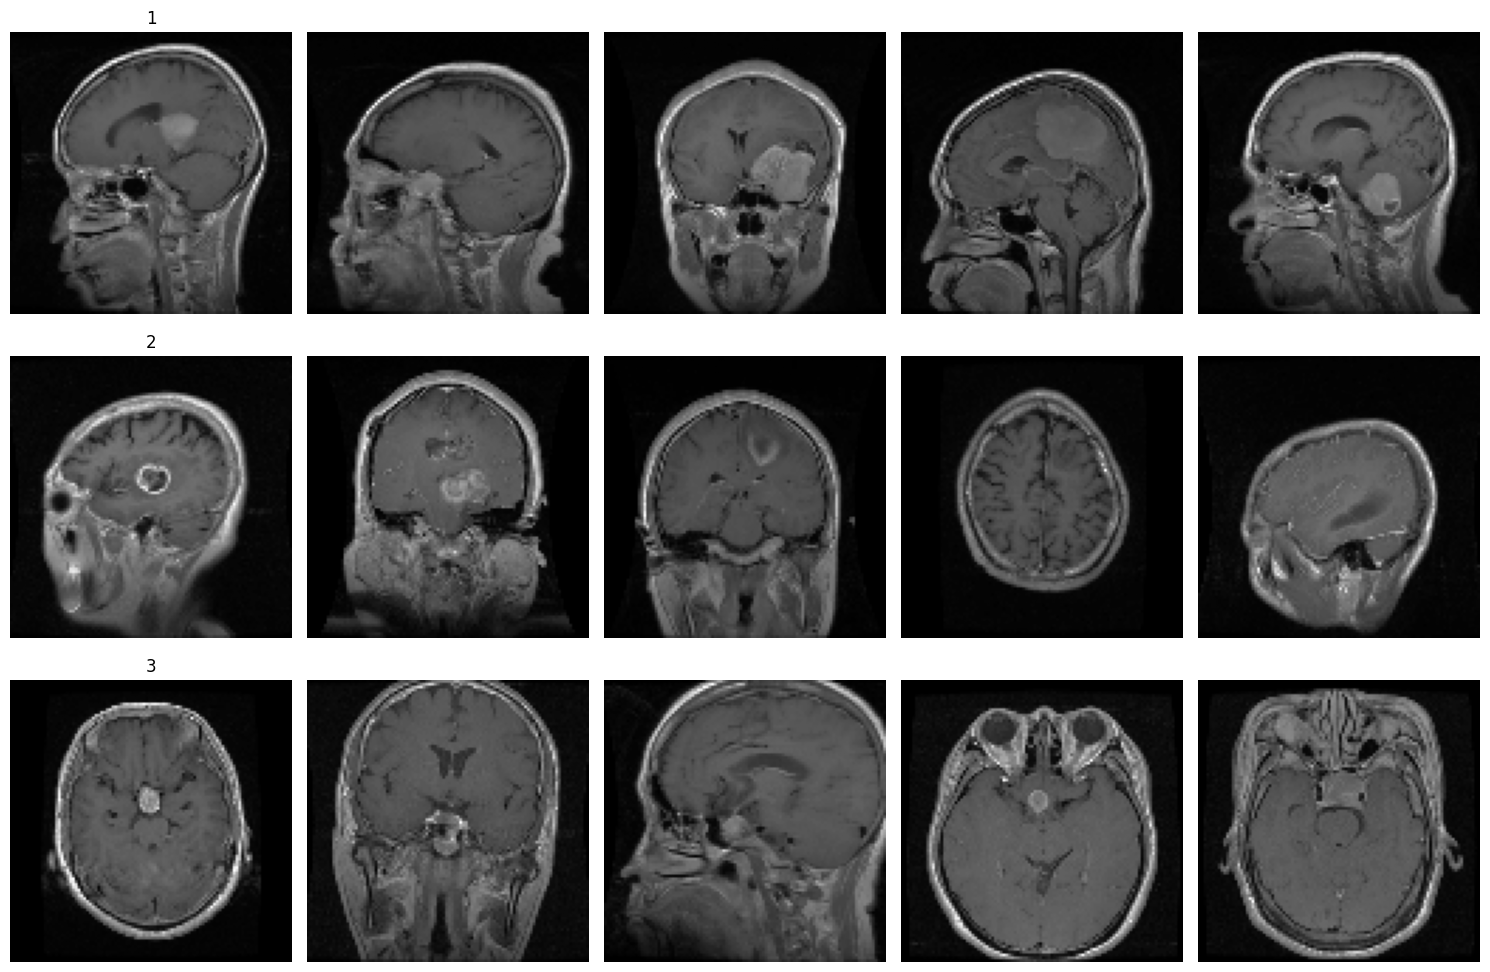

In [13]:
#Display Sample Images
import matplotlib.pyplot as plt
import cv2
import random

def show_sample_images(dataset_path, num_samples=5):
    categories = os.listdir(dataset_path)
    fig, axes = plt.subplots(len(categories), num_samples, figsize=(15, 10))

    for i, category in enumerate(categories):
        category_path = os.path.join(dataset_path, category)
        images = random.sample(os.listdir(category_path), num_samples)

        for j, img_name in enumerate(images):
            img_path = os.path.join(category_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Read in grayscale
            img = cv2.resize(img, (100, 100))  # Resize for consistency
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(category)

    plt.tight_layout()
    plt.show()

show_sample_images(dataset_path)

## Checking dataset balance
To see if the dataset is balanced across classes:

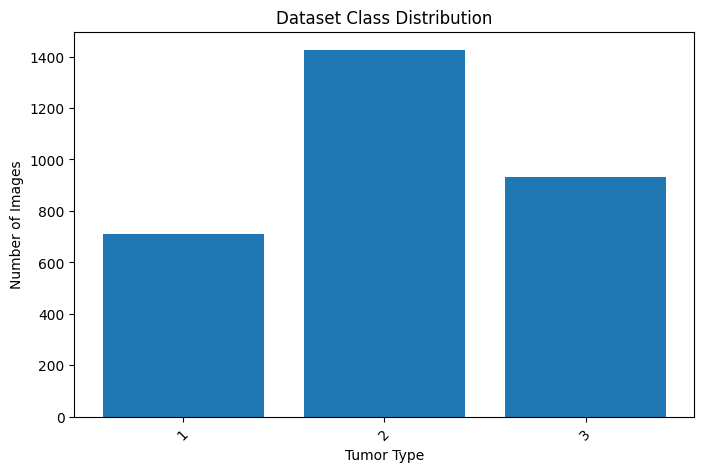

In [14]:
import pandas as pd

# Count images per category
data_counts = {category: len(os.listdir(os.path.join(dataset_path, category)))
               for category in os.listdir(dataset_path)}

# Convert to DataFrame
df = pd.DataFrame(list(data_counts.items()), columns=["Category", "Image Count"])

# Plot
plt.figure(figsize=(8,5))
plt.bar(df["Category"], df["Image Count"])
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution")
plt.xticks(rotation=45)
plt.show()


# Step 2: Data Preprocessing
Resize images to a consistent shape (e.g., 224x224 for CNNs).
Normalize pixel values (e.g., scale between 0 and 1).
Apply data augmentation to improve generalization.

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
IMG_SIZE = (224, 224)  # Image size
BATCH_SIZE = 32  # Number of images per training step
dataset_path = dataset_path  # The path from previous steps

# Define ImageDataGenerator for augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize pixel values
    rotation_range=20,  # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shearing
    zoom_range=0.2,  # Zoom
    horizontal_flip=True,  # Flip images horizontally
    validation_split=0.2  # Split 20% of data for validation
)

# Load training dataset
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # Because we have multiple tumor classes
    subset='training'
)

# Load validation dataset
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 2452 images belonging to 3 classes.
Found 612 images belonging to 3 classes.


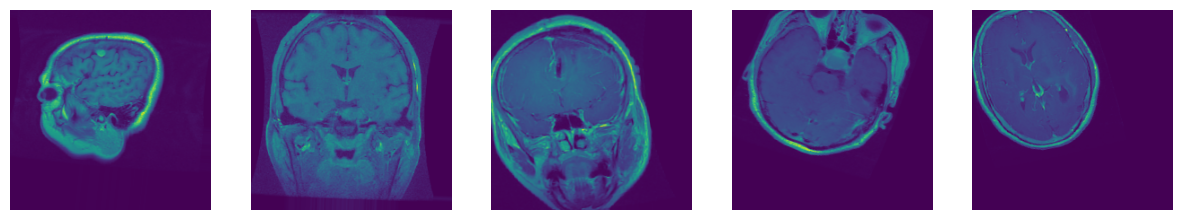

In [16]:
import matplotlib.pyplot as plt

# Get a batch of images
sample_images, sample_labels = next(train_generator)

# Plot sample images
fig, axes = plt.subplots(1, 5, figsize=(15,5))
for i in range(5):
    axes[i].imshow(sample_images[i])
    axes[i].axis('off')
plt.show()


In [17]:
print("Class labels:", train_generator.class_indices)


Class labels: {'1': 0, '2': 1, '3': 2}



# Step 3: Model Selection
Use a CNN (Convolutional Neural Network) for feature extraction.
Consider Transfer Learning (e.g., ResNet50, VGG16, EfficientNet).
Experiment with architectures to improve accuracy.


- Resize images to 224x224
- Normalize pixel values to [0, 1]
- Apply data augmentation
- Create train/validation splitsList item

-Using a pre-trained model like ResNet50, VGG16, or EfficientNet will speed up training and improve accuracy by leveraging features learned from millions of images.




## EfficientNetB0 Pre-trained Model
-lightweight, accurate, and optimized for deep learning on medical images.
-Models like EfficientNet, ResNet, and VGG16 were trained on ImageNet, which has RGB images.

In [20]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D

# Load EfficientNetB0 without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model (for feature extraction)
base_model.trainable = False

# Add custom layers on top
x = base_model.output  # Get EfficientNet output
x = GlobalAveragePooling2D()(x)  # Convert feature maps to a vector
x = Dense(512, activation='relu')(x)  # Fully connected layer
x = Dropout(0.3)(x)  # Dropout for regularization
output_layer = Dense(3, activation='softmax')(x)  # Output layer (3 classes)

# Define final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Show model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_4 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_2           │ (None, 224, 224, 3)    │              7 │ rescaling_4[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_5 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_5[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,706,982 (17.96 MB)

 Trainable params: 657,411 (2.51 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
# Define training parameters
EPOCHS = 10

# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 343s 4s/step - accuracy: 0.4058 - loss: 1.1423 - val_accuracy: 0.4657 - val_loss: 1.0775
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 332s 4s/step - accuracy: 0.4802 - loss: 1.0575 - val_accuracy: 0.4657 - val_loss: 1.0628
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.4658 - loss: 1.0619 - val_accuracy: 0.4657 - val_loss: 1.0574
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4696 - loss: 1.0600

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy & Loss
plt.figure(figsize=(10, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()


In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc:.2f}")


## Greyscale

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,  # Normalize
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    color_mode="grayscale"  # Load images as grayscale
)


In [ ]:
from tensorflow.keras.layers import Conv2D, Input

# Change input shape to grayscale
input_layer = Input(shape=(224, 224, 1))  # 1-channel grayscale input
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=input_layer)

# Ensure EfficientNet can handle grayscale input
x = Conv2D(3, (3,3), padding='same')(input_layer)  # Convert grayscale to RGB
x = base_model(x)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation='softmax')(x)

# Create the model
model = Model(inputs=input_layer, outputs=output_layer)



Step 3: Model Selection
Use a CNN (Convolutional Neural Network) for feature extraction.
Consider Transfer Learning (e.g., ResNet50, VGG16, EfficientNet).
Experiment with architectures to improve accuracy.

Step 4: Training the Model
Split the dataset into training, validation, and test sets.
Use categorical cross-entropy loss and Adam optimizer.
Monitor performance using accuracy and confusion matrices.

Step 5: Evaluation and Optimization
Tune hyperparameters (learning rate, batch size, dropout).
Implement early stopping and learning rate scheduling.
Generate a classification report with precision, recall, and F1-score.

Step 6: Deployment & Visualization
Deploy as a simple web app (Streamlit or Flask) for user-friendly interaction.
Visualize activations using Grad-CAM to interpret model decisions.